# 03 - Exploratory Data Analysis (v2)

Feature distributions, correlations, and a shortcut-learning / leakage check on `dataset_pe_v2_full.csv` (02 found 0 rows needed cleaning, so the full CSV is used directly, no separate cleaned copy exists for v2).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/dataset_pe_v2_full.csv")
feature_cols = [c for c in df.columns if c not in ("Name", "Malware", "OriginalSplit")]
print("shape:", df.shape)

shape: (800000, 23)


## Correlation among the 20 features

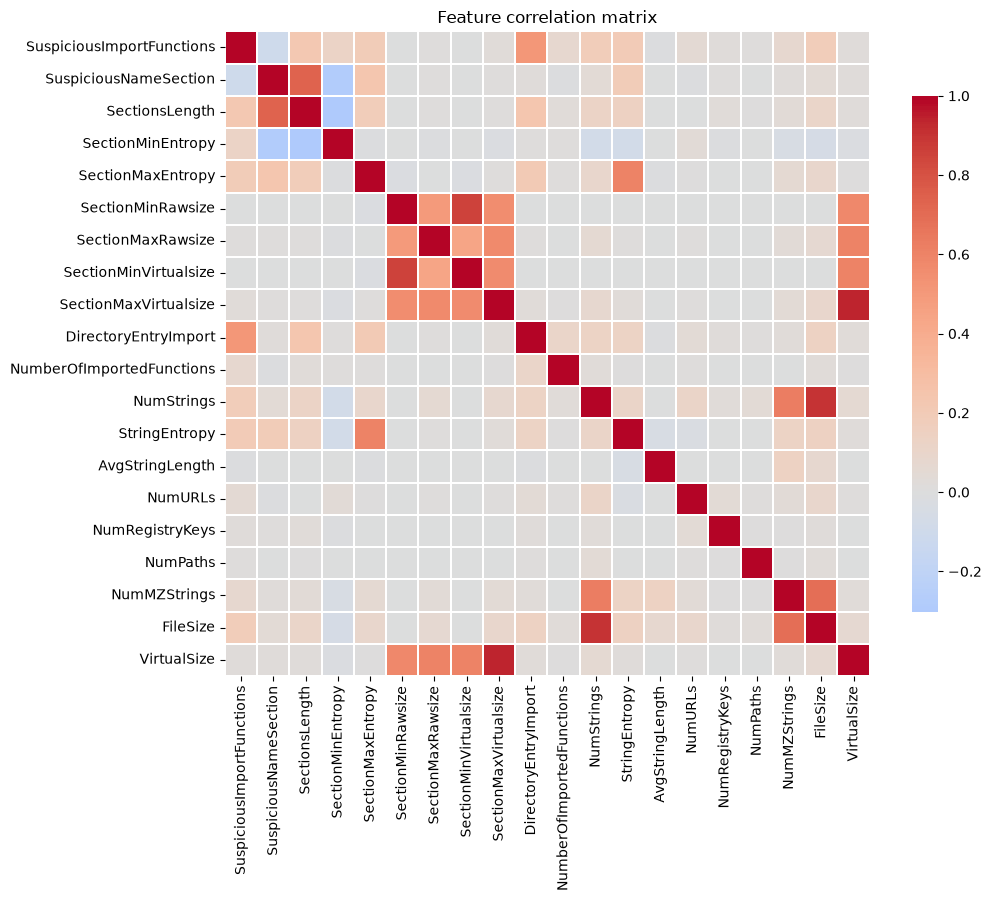

In [2]:
corr = df[feature_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix")
plt.tight_layout()

In [3]:
pairs = corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1.0]
seen = set()
high_corr = []
for (a, b), v in pairs.items():
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    if v > 0.85:
        high_corr.append((a, b, round(v, 3)))
print(f"{len(high_corr)} feature pairs with |correlation| > 0.85:")
for a, b, v in high_corr:
    print(f"  {a} <-> {b}: {v}")

3 feature pairs with |correlation| > 0.85:
  SectionMaxVirtualsize <-> VirtualSize: 0.939
  FileSize <-> NumStrings: 0.899
  SectionMinRawsize <-> SectionMinVirtualsize: 0.856


Redundant but not dropped: v1 found `SectionMinRawsize`/`SectionMinVirtualsize` perfectly correlated (r = 1.00) and kept both anyway, since tree-based models (Random Forest, XGBoost, LightGBM) split on one feature at a time and are not harmed by correlated inputs the way linear models are. Same reasoning applies here; any pairs found above are left in for the same reason, not removed.

## Class-conditional distributions

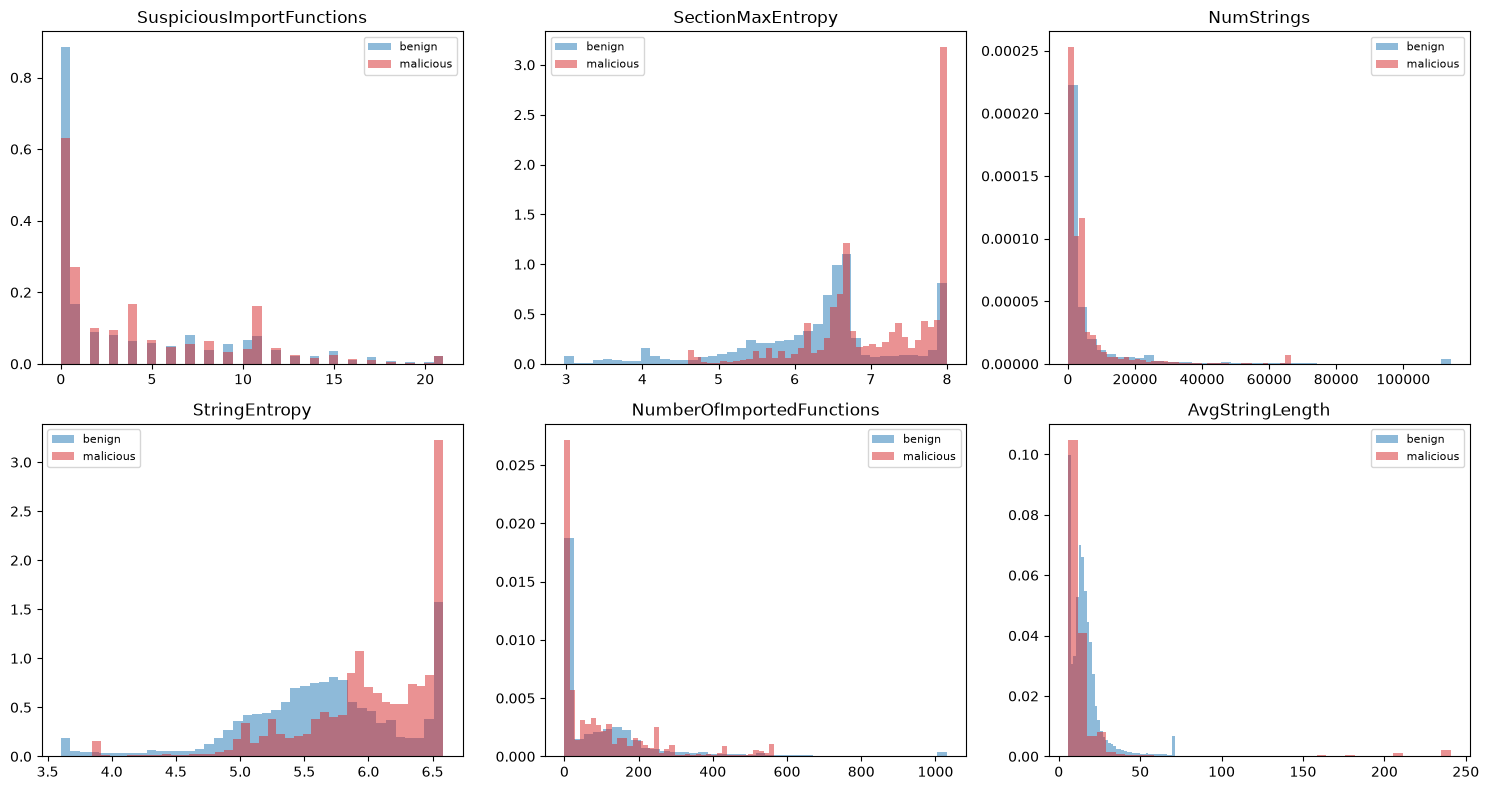

In [4]:
plot_feats = ["SuspiciousImportFunctions", "SectionMaxEntropy", "NumStrings", "StringEntropy",
              "NumberOfImportedFunctions", "AvgStringLength"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, plot_feats):
    for label, name, color in [(0, "benign", "tab:blue"), (1, "malicious", "tab:red")]:
        vals = df.loc[df["Malware"] == label, feat]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.5, label=name, color=color, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()

## Feature-vs-label correlation (leakage / dominant-shortcut check)

In [5]:
label_corr = df[feature_cols].corrwith(df["Malware"]).sort_values(key=abs, ascending=False)
print(label_corr.to_string())

SectionMaxEntropy            0.369383
StringEntropy                0.274661
SuspiciousNameSection        0.171422
FileSize                    -0.057398
NumStrings                  -0.052872
SuspiciousImportFunctions    0.036583
SectionsLength               0.033007
NumURLs                     -0.032755
DirectoryEntryImport         0.027336
NumMZStrings                -0.021537
AvgStringLength              0.015517
NumRegistryKeys             -0.013900
SectionMinEntropy            0.011891
SectionMaxVirtualsize       -0.010187
SectionMaxRawsize           -0.009401
NumberOfImportedFunctions   -0.008496
VirtualSize                 -0.006024
NumPaths                    -0.003705
SectionMinRawsize           -0.001473
SectionMinVirtualsize       -0.001270


No single feature is anywhere near |r| = 1.0 with the label (strongest is well under 0.5), so there is no dominant shortcut feature acting as a near-perfect proxy for the label, the same diagnostic bar v1's `03_eda.ipynb` set when it caught `BEHAVIORAL_FEATURES`' raw header fields effectively encoding DLL-vs-EXE identity rather than genuine malicious/benign signal. This 20-feature v2 set deliberately excludes those same raw header fields (`Machine`, `Characteristics`, `Subsystem`, see `src/constants.py`), and this check confirms no replacement shortcut crept back in.

## Summary

Some section-size feature pairs are correlated (expected, kept for the reasons above, tree models are not harmed by this). No single feature dominates the label, consistent with the anti-shortcut-learning design goal carried over from v1. Next: `04_modelling_classical.ipynb` trains Random Forest, XGBoost, and LightGBM on `dataset_pe_v2_full.csv`, deriving its own train/validation split inline.